# Linear Regression, Polynomial Regression & Regularized Linear Models

This notebook demonstrates three fundamental regression techniques in machine learning:
- **Linear Regression** – fitting a straight line to data
- **Polynomial Regression** – extending linear regression to capture non-linear relationships
- **Regularized Linear Models** – using Ridge regression to reduce overfitting

## Imports
We import the necessary libraries: NumPy for numerical operations, Pandas for data handling, Matplotlib and Seaborn for visualization, and scikit-learn for machine learning utilities.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score,accuracy_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge

---
## Part 1 – Linear Regression

### 1.1 Generate Synthetic Data
We generate 100 random samples following the linear relationship:
$$y = 4 + 3x_1 + \text{Gaussian noise}$$
This will be our training data.

In [2]:
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

### 1.2 Visualize the Raw Data
A scatter plot of the generated data points helps us see the underlying linear trend before fitting any model.

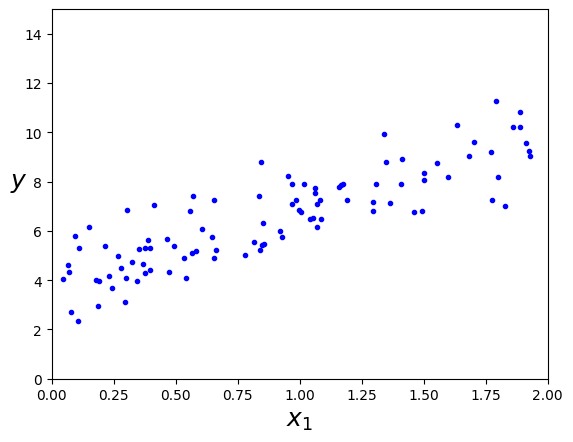

In [3]:
plt.plot(X, y, "b.")
plt.xlabel("$x_1$", fontsize=18)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.axis([0, 2, 0, 15])
plt.show()

### 1.3 The Normal Equation (Closed-Form Solution)
The **Normal Equation** computes the optimal model parameters $\hat{\theta}$ analytically:
$$\hat{\theta} = (X^T \cdot X)^{-1} \cdot X^T \cdot y$$
We first augment `X` with a bias column of ones (`X_b`), then apply the formula directly.

In [4]:
X_b = np.c_[np.ones((100, 1)), X] 
theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)

### 1.4 Make Predictions with the Normal Equation
Using the computed $\hat{\theta}$, we predict `y` values for two new data points (`x=0` and `x=2`).

In [5]:
X_new = np.array([[0], [2]])
X_new_b = np.c_[np.ones((2, 1)), X_new] 
y_predict = X_new_b.dot(theta_best)
y_predict

array([[3.87028171],
       [9.84700906]])

### 1.5 Plot the Regression Line
We overlay the predicted regression line (red) on top of the original data scatter (blue dots).

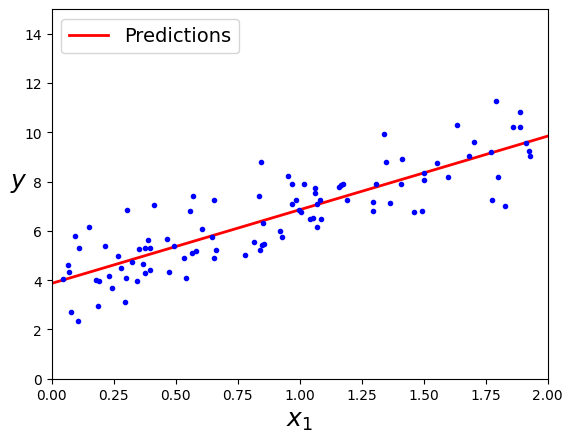

In [6]:
plt.plot(X_new, y_predict, "r-", linewidth=2, label="Predictions")
plt.plot(X, y, "b.")
plt.xlabel("$x_1$", fontsize=18)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.legend(loc="upper left", fontsize=14)
plt.axis([0, 2, 0, 15])
plt.show()

### 1.6 Linear Regression with scikit-learn
scikit-learn's `LinearRegression` class also uses the Normal Equation internally.
We fit it on the same data and inspect the learned intercept and coefficients.

In [7]:
lin_reg = LinearRegression()
lin_reg.fit(X, y)
lin_reg.intercept_, lin_reg.coef_

(array([3.87028171]), array([[2.98836367]]))

### 1.7 Predictions using scikit-learn
We use the fitted `LinearRegression` model to predict `y` for the same new data points.
The results should match those obtained via the Normal Equation above.

In [8]:
lin_reg.predict(X_new)

array([[3.87028171],
       [9.84700906]])

---
## Part 2 – Polynomial Regression

### 2.1 Generate Non-Linear Data
We generate 100 samples following a **quadratic** relationship:
$$y = 0.5x_1^2 + x_1 + 2 + \text{Gaussian noise}$$
A straight line would not fit this data well — we need polynomial features.

In [9]:
np.random.seed(42)
m = 100
X = 6 * np.random.rand(m, 1) - 3
y = 0.5 * X**2 + X + 2 + np.random.randn(m, 1)

### 2.2 Visualize the Non-Linear Data
The scatter plot reveals a clear curved (quadratic) pattern in the data.

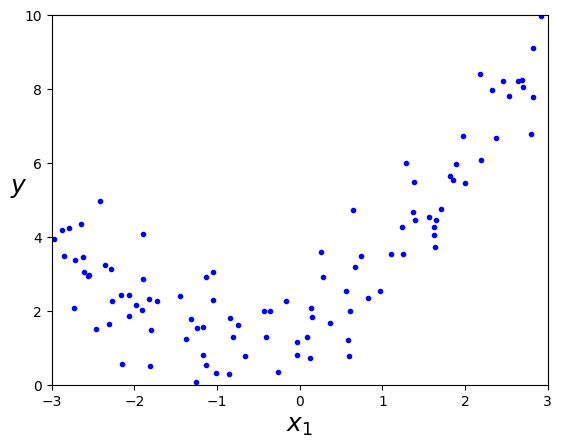

In [10]:
plt.plot(X, y, "b.")
plt.xlabel("$x_1$", fontsize=18)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.axis([-3, 3, 0, 10])
plt.show()

### 2.3 Create Polynomial Features (degree=2)
`PolynomialFeatures` transforms the original feature `x` into `[x, x²]`.
This allows a linear model to learn non-linear relationships by fitting a polynomial curve.

In [11]:
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)
X[0]

array([-0.75275929])

### 2.4 Fit Linear Regression on Polynomial Features
We train `LinearRegression` on the expanded feature matrix `X_poly`.
The learned coefficients correspond to the quadratic equation parameters.

In [12]:
lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)
lin_reg.intercept_, lin_reg.coef_

(array([1.78134581]), array([[0.93366893, 0.56456263]]))

### 2.5 Plot the Polynomial Regression Curve
We generate predictions over a smooth range `[-3, 3]` and plot the fitted polynomial curve.

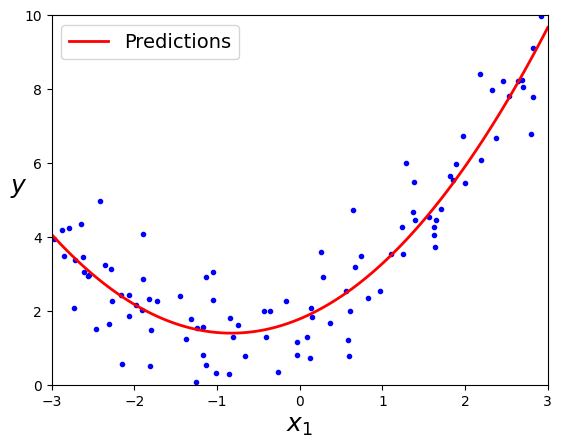

In [13]:
X_new=np.linspace(-3, 3, 100).reshape(100, 1)
X_new_poly = poly_features.transform(X_new)
y_new = lin_reg.predict(X_new_poly)
plt.plot(X, y, "b.")
plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions")
plt.xlabel("$x_1$", fontsize=18)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.legend(loc="upper left", fontsize=14)
plt.axis([-3, 3, 0, 10])
plt.show()

### 2.6 Comparing Polynomial Degrees (Bias vs. Variance Trade-off)
We fit three models with different polynomial degrees:
- **Degree 1** (linear) – underfits (high bias)
- **Degree 2** (quadratic) – good fit
- **Degree 300** – massively overfits (high variance)

The plot illustrates the classic **bias-variance trade-off**.

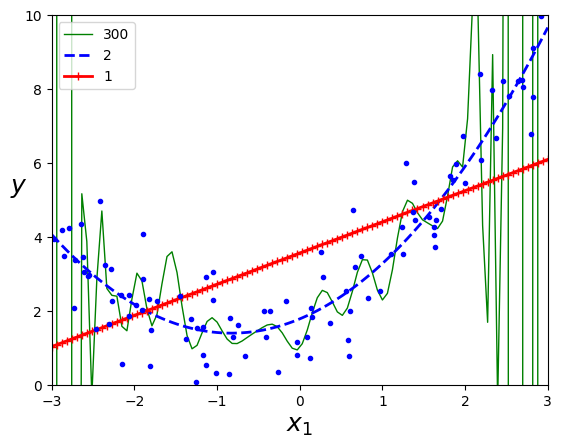

In [14]:
for style, width, degree in (("g-", 1, 300), ("b--", 2, 2), ("r-+", 2, 1)):
    polybig_features = PolynomialFeatures(degree=degree, include_bias=False)
    std_scaler = StandardScaler()
    lin_reg = LinearRegression()
    polynomial_regression = Pipeline([
            ("poly_features", polybig_features),
            ("std_scaler", std_scaler),
            ("lin_reg", lin_reg),
        ])
    polynomial_regression.fit(X, y)
    y_newbig = polynomial_regression.predict(X_new)
    plt.plot(X_new, y_newbig, style, label=str(degree), linewidth=width)

plt.plot(X, y, "b.", linewidth=3)
plt.legend(loc="upper left")
plt.xlabel("$x_1$", fontsize=18)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.axis([-3, 3, 0, 10])
plt.show()

---
## Part 3 – Regularized Linear Models (Ridge Regression)

### 3.1 Generate New Sample Data
We generate a smaller dataset (20 points) with a mild linear relationship plus noise,
which makes regularization more impactful and easier to observe.

In [15]:
np.random.seed(42)
m = 20
X = 3 * np.random.rand(m, 1)
y = 1 + 0.5 * X + np.random.randn(m, 1) / 1.5
X_new = np.linspace(0, 3, 100).reshape(100, 1)

### 3.2 Ridge Regression – Cholesky Solver
**Ridge regression** adds an L2 penalty term to the cost function:
$$J(\theta) = \text{MSE}(\theta) + \alpha \sum_{i=1}^{n} \theta_i^2$$
The parameter `alpha` controls regularization strength. Higher `alpha` → smoother, less complex model.
Here we use the **Cholesky** direct solver.

In [16]:
ridge_reg = Ridge(alpha=1, solver="cholesky", random_state=42)
ridge_reg.fit(X, y)
ridge_reg.predict([[1.5]])

array([1.55071465])

### 3.3 Ridge Regression – SAG Solver
We repeat Ridge regression using the **Stochastic Average Gradient (SAG)** solver.
Both solvers should produce nearly identical predictions — the solver choice mainly affects performance on large datasets.

In [17]:
ridge_reg = Ridge(alpha=1, solver="sag", random_state=42)
ridge_reg.fit(X, y)
ridge_reg.predict([[1.5]])

array([1.55072189])

### 3.4 Visualize Ridge Regression with Varying Alpha
We plot Ridge regression curves for multiple `alpha` values:
- **Small alpha** → model closely follows training data (risk of overfitting)
- **Large alpha** → model is smoother and more regularized (risk of underfitting)

Both polynomial and plain linear versions are shown side-by-side.

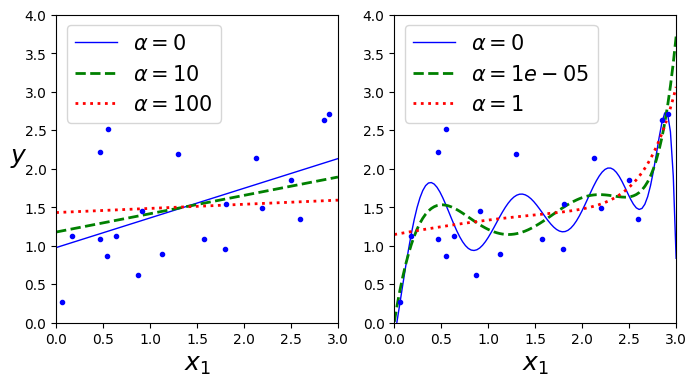

In [18]:
def plot_model(model_class, polynomial, alphas, **model_kargs):
    for alpha, style in zip(alphas, ("b-", "g--", "r:")):
        model = model_class(alpha, **model_kargs) if alpha > 0 else LinearRegression()
        if polynomial:
            model = Pipeline([
                    ("poly_features", PolynomialFeatures(degree=10, include_bias=False)),
                    ("std_scaler", StandardScaler()),
                    ("regul_reg", model),
                ])
        model.fit(X, y)
        y_new_regul = model.predict(X_new)
        lw = 2 if alpha > 0 else 1
        plt.plot(X_new, y_new_regul, style, linewidth=lw, label=r"$\alpha = {}$".format(alpha))
    plt.plot(X, y, "b.", linewidth=3)
    plt.legend(loc="upper left", fontsize=15)
    plt.xlabel("$x_1$", fontsize=18)
    plt.axis([0, 3, 0, 4])

plt.figure(figsize=(8,4))
plt.subplot(121)
plot_model(Ridge, polynomial=False, alphas=(0, 10, 100), random_state=42)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.subplot(122)
plot_model(Ridge, polynomial=True, alphas=(0, 10**-5, 1), random_state=42)
plt.show()